# Machine RUL Prediction — NASA C-MAPSS FD001

**Author:** Pallavi

## Baseline Linear Regression

The previous notebooks helped me understand and prepare the FD001 dataset.

Now I want to establish a baseline Linear Regression model.

The purpose of this model is not to achieve the best possible score immediately. Instead, it gives me a clear starting point against which I can compare later improvements.

I will evaluate the model using MAE, RMSE, and R².

## 1. Preparing the Data for Modeling

I will use the finalized preprocessing logic to create the training and validation datasets before fitting the baseline model.

In [1]:
# Importing required libraries

import sys
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("../")

from src.preprocessing import load_training_data, remove_constant_features

## 1. Preparing the Data for Modeling

I will use the finalized preprocessing functions to load the training data, create RUL, and remove constant features before model training.

In [2]:
# Loading and preprocessing the training data

train_df = load_training_data("../data/raw/train_FD001.txt")

train_df, constant_columns = remove_constant_features(train_df)

print("Dataset shape:", train_df.shape)
print("Removed columns:", constant_columns.tolist())

Dataset shape: (20631, 20)
Removed columns: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


## 2. Creating the Training and Validation Sets

I will keep the engine-level split so that validation contains completely unseen engines.

In [3]:
# Splitting engines for validation

engine_ids = train_df["unit_id"].unique()

train_units, val_units = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train_df[train_df["unit_id"].isin(train_units)]
val_data = train_df[train_df["unit_id"].isin(val_units)]

# Preparing model inputs

X_train = train_data.drop(columns=["unit_id", "RUL"])
y_train = train_data["RUL"]

X_val = val_data.drop(columns=["unit_id", "RUL"])
y_val = val_data["RUL"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (16561, 18)
X_val: (4070, 18)


## 3. Training the Baseline Linear Regression

I will now train a basic Linear Regression model to establish the first performance benchmark for the project.

In [5]:
# Training the baseline model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 4. Generating RUL Predictions

The baseline model has learned from the training engines. I will now use it to predict RUL for the unseen validation engines.

In [6]:
# Predicting RUL for unseen engines
y_pred = model.predict(X_val)
y_pred[:5]

array([179.22091889, 175.28349843, 184.36968092, 192.27850452,
       176.58830734])

## 5. Evaluating the Baseline Model

I will compare the predicted RUL with the actual RUL using MAE, RMSE, and R².

These metrics will give us a clear baseline for evaluating improvements later.

In [7]:
# Calculating baseline performance

mae = mean_absolute_error(y_val, y_pred)
rmse = mean_squared_error(y_val, y_pred) ** 0.5
r2 = r2_score(y_val, y_pred)
print(f"MAE : {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²  : {r2:.3f}")

MAE : 25.16 cycles
RMSE: 31.66 cycles
R²  : 0.768


## 6. Baseline Model Findings

The baseline Linear Regression model achieved an MAE of 25.16 cycles, meaning that its RUL predictions were approximately 25 cycles away from the actual values on average.

The RMSE of 31.66 cycles is higher than the MAE, indicating that some predictions contain larger errors.

The model achieved an R² of 0.768, showing that the sensor measurements explain a substantial portion of the variation in RUL.

This provides a reasonable baseline, but the difference between MAE and RMSE suggests that the model still makes some large prediction errors. I will investigate these errors before deciding how to improve the model.

## 7. Comparing Actual and Predicted RUL

The baseline metrics show that the model has room for improvement. I will now compare actual and predicted RUL values to see how closely the model follows the true values.

In [9]:
# Importing required libraries

import sys
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("../")

from src.preprocessing import load_training_data, remove_constant_features

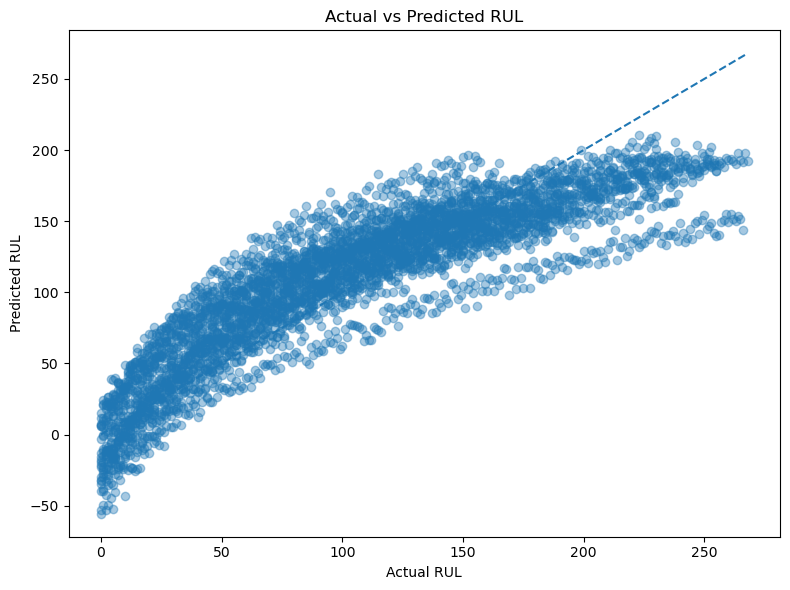

In [10]:
# Comparing actual and predicted RUL

plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred, alpha=0.4)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted RUL")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.tight_layout()

plt.savefig(
    "../reports/figures/actual_vs_predicted_rul.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Understanding Prediction Errors

The actual-versus-predicted plot shows how closely the model follows the true RUL. I will now examine the errors directly to understand the size and direction of its mistakes.

In [11]:
# Calculating prediction errors

errors = y_val - y_pred

print("Mean error:", errors.mean())
print("Minimum error:", errors.min())
print("Maximum error:", errors.max())

Mean error: -3.280087689632764
Minimum error: -76.26099137593701
Maximum error: 122.06964938236342


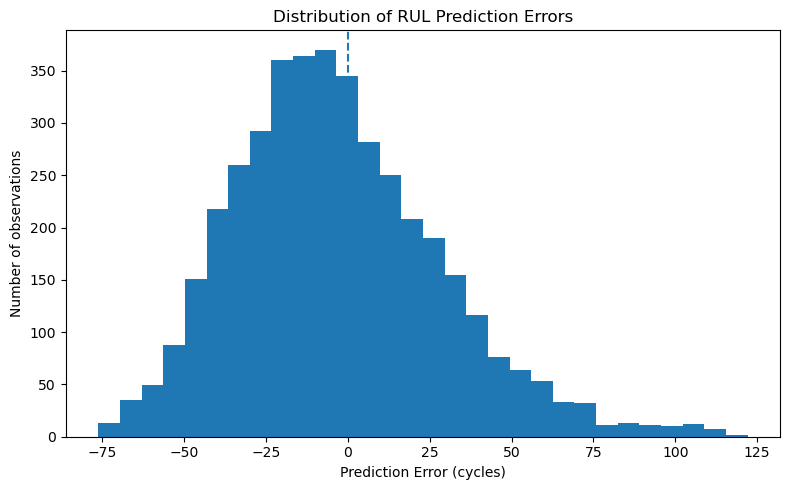

In [12]:
# Plotting the error distribution

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=30)

plt.axvline(0, linestyle="--")

plt.title("Distribution of RUL Prediction Errors")
plt.xlabel("Prediction Error (cycles)")
plt.ylabel("Number of observations")
plt.tight_layout()

plt.savefig(
    "../reports/figures/rul_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Understanding Feature Influence

The baseline model uses several sensor and operating-condition features. I will examine the learned coefficients to understand which features have the strongest influence on the predicted RUL.

In [13]:
# Checking feature coefficients

coefficients = pd.Series(
    model.coef_,
    index=X_train.columns
)

coefficients.sort_values()

sensor_6     -236.060605
setting_1    -164.638959
sensor_15     -84.361421
sensor_8      -29.393908
sensor_11     -24.701715
sensor_13     -15.119290
sensor_2       -5.728358
sensor_17      -0.997532
sensor_4       -0.432508
cycle          -0.383911
sensor_3       -0.286751
sensor_14      -0.195774
sensor_9       -0.140302
sensor_7        4.375752
sensor_12       5.161079
sensor_20       8.685957
sensor_21      26.440955
setting_2    3467.225516
dtype: float64

In [14]:
# Finding the strongest model coefficients

coefficient_strength = coefficients.abs().sort_values(ascending=False)

coefficient_strength

setting_2    3467.225516
sensor_6      236.060605
setting_1     164.638959
sensor_15      84.361421
sensor_8       29.393908
sensor_21      26.440955
sensor_11      24.701715
sensor_13      15.119290
sensor_20       8.685957
sensor_2        5.728358
sensor_12       5.161079
sensor_7        4.375752
sensor_17       0.997532
sensor_4        0.432508
cycle           0.383911
sensor_3        0.286751
sensor_14       0.195774
sensor_9        0.140302
dtype: float64

In [15]:
# Finding the strongest model coefficients

coefficient_strength = coefficients.abs().sort_values(ascending=False)

coefficient_strength

setting_2    3467.225516
sensor_6      236.060605
setting_1     164.638959
sensor_15      84.361421
sensor_8       29.393908
sensor_21      26.440955
sensor_11      24.701715
sensor_13      15.119290
sensor_20       8.685957
sensor_2        5.728358
sensor_12       5.161079
sensor_7        4.375752
sensor_17       0.997532
sensor_4        0.432508
cycle           0.383911
sensor_3        0.286751
sensor_14       0.195774
sensor_9        0.140302
dtype: float64

## 11. Standardizing Features

The sensor measurements are recorded on different numerical scales, so their raw Linear Regression coefficients cannot be directly compared.

I will standardize the features using the training data so that the coefficients can be compared more fairly.

In [16]:
# Importing the feature scaler

from sklearn.preprocessing import StandardScaler

In [18]:
# Fitting the scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [19]:
# Training Linear Regression on standardized features

scaled_model = LinearRegression()

scaled_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
# Checking standardized coefficients

scaled_coefficients = pd.Series(
    scaled_model.coef_,
    index=X_train.columns
)

scaled_coefficients.abs().sort_values(ascending=False)

cycle        26.734727
sensor_11     6.563873
sensor_4      3.877581
sensor_7      3.840797
sensor_14     3.834518
sensor_12     3.793227
sensor_9      3.179112
sensor_15     3.164141
sensor_2      2.853348
sensor_21     2.839811
sensor_8      2.076532
sensor_3      1.744946
sensor_20     1.562317
sensor_17     1.542454
sensor_13     1.084151
setting_2     1.014622
setting_1     0.360657
sensor_6      0.321950
dtype: float64

In [23]:
# Checking coefficient direction

scaled_coefficients.sort_values(ascending=False)

sensor_7      3.840797
sensor_12     3.793227
sensor_21     2.839811
sensor_20     1.562317
setting_2     1.014622
sensor_6     -0.321950
setting_1    -0.360657
sensor_13    -1.084151
sensor_17    -1.542454
sensor_3     -1.744946
sensor_8     -2.076532
sensor_2     -2.853348
sensor_15    -3.164141
sensor_9     -3.179112
sensor_14    -3.834518
sensor_4     -3.877581
sensor_11    -6.563873
cycle       -26.734727
dtype: float64

## 11. Interpreting Feature Influence

After standardizing the features, the Linear Regression coefficients can be compared more fairly because the features are now on the same scale.

The strongest coefficients in the model are:

- **cycle (-26.73):** As the engine completes more cycles, its predicted RUL decreases. This is expected because an engine has less remaining life as it operates for more cycles.
- **sensor_11 (-6.56):** Higher values are associated with lower predicted RUL in the fitted model.
- **sensor_4 (-3.88):** Higher values are associated with lower predicted RUL.
- **sensor_14 (-3.83):** Higher values are associated with lower predicted RUL.
- **sensor_7 (+3.84):** Higher values are associated with higher predicted RUL.
- **sensor_12 (+3.79):** Higher values are associated with higher predicted RUL.

The coefficient sign shows the direction of the relationship, while the absolute value shows its strength in the standardized model.

These coefficients describe relationships learned by the model; they should not be interpreted as proof that a sensor directly causes changes in engine life.

### Finding

The analysis shows that `cycle` has the strongest influence in the baseline model, followed by several sensor measurements. Some sensors have positive relationships with predicted RUL, while others have negative relationships.

However, coefficient strength alone is not enough to decide which features should be removed. I will therefore compare the full feature model with a selected-feature model using MAE, RMSE, and R² before making a feature-selection decision.

## 12. Selecting the Strongest Features

The standardized coefficients showed that some features have a stronger influence on the baseline model than others.

Instead of removing features arbitrarily, I will test whether keeping the strongest features can improve validation performance.

I will select the top 10 features based on the absolute standardized coefficients.

In [24]:
# Selecting the top 10 features

top_features = scaled_coefficients.abs().sort_values(
    ascending=False
).head(10).index

top_features

Index(['cycle', 'sensor_11', 'sensor_4', 'sensor_7', 'sensor_14', 'sensor_12',
       'sensor_9', 'sensor_15', 'sensor_2', 'sensor_21'],
      dtype='object')

## 13. Training a Selected-Feature Model

I will now train a second Linear Regression model using only the selected features.

The purpose is to determine whether a smaller feature set can perform better than the full feature model.

In [25]:
# Preparing the selected features

X_train_selected = X_train[top_features]
X_val_selected = X_val[top_features]

# Standardizing the selected features

selected_scaler = StandardScaler()

X_train_selected_scaled = selected_scaler.fit_transform(
    X_train_selected
)

X_val_selected_scaled = selected_scaler.transform(
    X_val_selected
)

# Training the selected-feature model

selected_model = LinearRegression()

selected_model.fit(
    X_train_selected_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 14. Evaluating the Selected-Feature Model

I will compare the selected-feature model with the original baseline using the same validation data and the same evaluation metrics.

In [26]:
# Evaluating the selected-feature model

selected_pred = selected_model.predict(
    X_val_selected_scaled
)

selected_mae = mean_absolute_error(
    y_val,
    selected_pred
)

selected_rmse = mean_squared_error(
    y_val,
    selected_pred
) ** 0.5

selected_r2 = r2_score(
    y_val,
    selected_pred
)

print(f"MAE : {selected_mae:.2f} cycles")
print(f"RMSE: {selected_rmse:.2f} cycles")
print(f"R²  : {selected_r2:.3f}")

MAE : 25.21 cycles
RMSE: 31.74 cycles
R²  : 0.766


## 15. Feature Selection Finding

The selected-feature model achieved an MAE of 25.21 cycles, RMSE of 31.74 cycles, and R² of 0.766.

Compared with the full-feature baseline, the selected-feature model performed slightly worse across all three metrics.

This suggests that the features with smaller individual coefficients may still provide useful information when combined with the other features.

Therefore, I will retain the full feature set for the next modeling stage instead of removing features based only on coefficient strength.

In [27]:
# Checking prediction accuracy at different tolerances

accuracy_10 = (abs(y_val - y_pred) <= 10).mean() * 100
accuracy_20 = (abs(y_val - y_pred) <= 20).mean() * 100
accuracy_30 = (abs(y_val - y_pred) <= 30).mean() * 100

print(f"Within ±10 cycles: {accuracy_10:.2f}%")
print(f"Within ±20 cycles: {accuracy_20:.2f}%")
print(f"Within ±30 cycles: {accuracy_30:.2f}%")

Within ±10 cycles: 24.84%
Within ±20 cycles: 46.83%
Within ±30 cycles: 65.85%


## 16. Moving Beyond Basic Linear Regression

The baseline Linear Regression model provides a useful starting point, but the sensor features may contain overlapping information. This can lead to large or unstable model coefficients.

To handle this, I will test two regularized regression methods: Ridge and Lasso.

**Ridge Regression** adds a penalty that reduces large coefficients while generally keeping all features in the model.

**Lasso Regression** also penalizes large coefficients, but it can reduce some coefficients completely to zero, which can effectively remove less useful features.

I will compare both methods with the baseline using MAE, RMSE, and R² to determine whether regularization improves RUL prediction.

## 17. Training Ridge Regression

Ridge Regression adds a penalty to large coefficients. I will first train a basic Ridge model using the standardized features and compare its performance with the baseline Linear Regression model.

In [28]:
# Training the Ridge model

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


## 18. Evaluating Ridge Regression

I will evaluate Ridge on the same unseen validation engines using the same metrics as the baseline model.

In [29]:
# Predicting with Ridge

ridge_pred = ridge_model.predict(X_val_scaled)

# Calculating Ridge performance

ridge_mae = mean_absolute_error(y_val, ridge_pred)
ridge_rmse = mean_squared_error(y_val, ridge_pred) ** 0.5
ridge_r2 = r2_score(y_val, ridge_pred)

print(f"MAE : {ridge_mae:.2f} cycles")
print(f"RMSE: {ridge_rmse:.2f} cycles")
print(f"R²  : {ridge_r2:.3f}")

MAE : 25.16 cycles
RMSE: 31.66 cycles
R²  : 0.768


## 19. Ridge Regression Finding

The Ridge model with `alpha = 1.0` produced almost the same validation performance as the baseline Linear Regression model.

The MAE, RMSE, and R² remained effectively unchanged.

This suggests that a small Ridge penalty does not provide a noticeable improvement for the current feature set. I will therefore test Lasso Regression next before deciding which regularization approach is more useful.

## 20. Training Lasso Regression

Lasso Regression adds a penalty that can reduce some feature coefficients to zero. I will test whether this regularization approach can improve prediction performance while also simplifying the feature set.

In [30]:
# Training the Lasso model

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [31]:
# Evaluating the Lasso model

lasso_pred = lasso_model.predict(X_val_scaled)

lasso_mae = mean_absolute_error(y_val, lasso_pred)
lasso_rmse = mean_squared_error(y_val, lasso_pred) ** 0.5
lasso_r2 = r2_score(y_val, lasso_pred)

print(f"MAE : {lasso_mae:.2f} cycles")
print(f"RMSE: {lasso_rmse:.2f} cycles")
print(f"R²  : {lasso_r2:.3f}")

MAE : 25.15 cycles
RMSE: 31.66 cycles
R²  : 0.767


## 21. Comparing the Regression Models

The three regression models produced very similar validation results.

Linear Regression achieved an MAE of 25.16 cycles, RMSE of 31.66 cycles, and R² of 0.768.

Ridge Regression with `alpha = 1.0` produced almost identical results.

Lasso Regression with `alpha = 0.1` produced a very small improvement in MAE, but its R² was slightly lower.

Overall, none of the regularized models produced a meaningful improvement over the baseline Linear Regression model.

This suggests that simply adding regularization is not enough to substantially improve the current model.

## 22. RUL Capping

The RUL target contains very high values during the early life of an engine. During this stage, the engine may show relatively stable operating behavior, while the main prediction challenge is the degradation phase.

I will therefore test whether capping very high RUL values can help the model focus more on the useful degradation pattern.

The original RUL target will be kept unchanged so that the two approaches can be compared fairly.

In [32]:
# Creating a capped RUL target

y_train_capped = y_train.clip(upper=125)

print("Original maximum RUL:", y_train.max())
print("Capped maximum RUL:", y_train_capped.max())

Original maximum RUL: 361
Capped maximum RUL: 125


In [33]:
# Training Linear Regression with capped RUL

capped_model = LinearRegression()

capped_model.fit(
    X_train_scaled,
    y_train_capped
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
# Evaluating the capped-RUL model

capped_pred = capped_model.predict(X_val_scaled)

capped_mae = mean_absolute_error(y_val, capped_pred)
capped_rmse = mean_squared_error(y_val, capped_pred) ** 0.5
capped_r2 = r2_score(y_val, capped_pred)

print(f"MAE : {capped_mae:.2f} cycles")
print(f"RMSE: {capped_rmse:.2f} cycles")
print(f"R²  : {capped_r2:.3f}")

MAE : 31.39 cycles
RMSE: 43.43 cycles
R²  : 0.562


## 23. RUL Capping Finding

The RUL target was capped at 125 cycles to test whether reducing the influence of very high RUL values would improve prediction performance.

However, the capped-RUL model performed substantially worse than the original Linear Regression model. Its MAE increased from 25.16 to 31.39 cycles, RMSE increased from 31.66 to 43.43 cycles, and R² decreased from 0.768 to 0.562.

This indicates that the higher RUL values contain useful information for this dataset. Therefore, I will retain the original uncapped RUL target for further modeling.